## Ekman Spiral

- An elementary upper ocean Ekman layer.
- Solve a 1-D diffusion flow numerically.
- This version has rotation, and thus makes an Ekman layer.
- The IC is a state of rest.
- The fluid is forced by an imposed stress at the top of the column (z=0)
- The lower boundary condition is free-slip to minimizethe effect of finite depth.

Original code by Jim Price, Oct 99
Modified version by Marcello Vichi, for UCT Oceanography
Translated from MATLAB to Python

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3D projection)

In [8]:
# %% user inputs
dz = 5.          # [m] grid interval
L = 100.          # [m] water column depth
ndays = 20.       # [day] days to integrate
A = 5.e-2         # [m2/s] the eddy diffusivity
Tauwy = 0.1       # [N/m2=Pa] the wind stress (y)
Tauwx = 0.        # [N/m2=Pa] the wind stress (x)
lat = -45.        # [deg] specify the latitude here
# plot profiles every nplot steps
nplot = 25

# constants
omega = 7.29e-5   # [s-1] 2pi/86400
rho0 = 1025.      # [kg/m3] nominal constant density of water
SECPERDAY = 86400
w = 0.4           # the Courant number dt*A/dz^2
                  # must be less than 0.5 for numerical stability

In [9]:
# grid specifications
z = np.arange(0, -L - dz, -dz)      # the grid definition
nz = z.size
dt = w * dz**2 / A                  # the time step is derived from the Courant number
nstep = round(ndays * SECPERDAY / dt)  # number of steps per day
time = np.zeros(nstep)

# derived parameters
f = 2. * omega * np.sin(lat * np.pi / 180)   # the Coriolis parameter
IP = (2 * np.pi / abs(f)) / SECPERDAY        # inertial period

# %% Variables and Initial conditions
u = np.zeros(nz)            # the dependent variable, velocity
v = u.copy()
uavg = u.copy()
vavg = u.copy()
navg = 0

Text(0.5, 0, 'Meridional current, [m/s]')

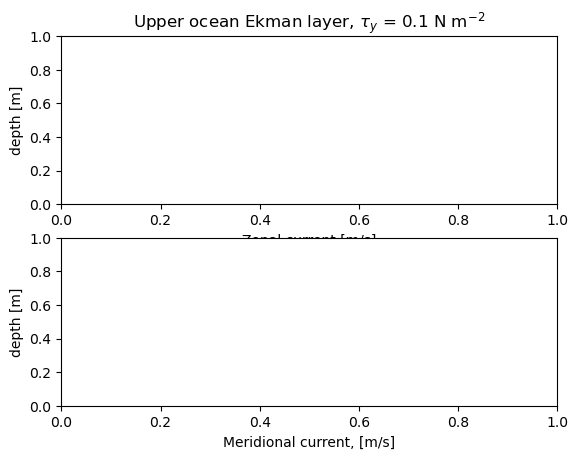

In [10]:
# set figure attributes
f1, (ax1, ax2) = plt.subplots(2, 1)
ax1.set_ylabel('depth [m]')
ax1.set_xlabel('Zonal current [m/s]')
ax1.set_title(r'Upper ocean Ekman layer, $\tau_y$ = 0.1 N m$^{-2}$')

ax2.set_ylabel('depth [m]')
ax2.set_xlabel('Meridional current, [m/s]')


In [11]:
# %% pre-allocate diagnostic time series
usurf = np.zeros(nstep)
vsurf = np.zeros(nstep)
umid = np.zeros(nstep)
vmid = np.zeros(nstep)
udeep = np.zeros(nstep)
vdeep = np.zeros(nstep)
transu = np.zeros(nstep)
transv = np.zeros(nstep)


# %%
# begin time-stepping
ht = None  # handle for the time string in the figure
for n in range(1, nstep + 1):
    idx = n - 1  # Python arrays are 0-based, MATLAB's are 1-based

    # advance time
    time[idx] = (n - 1) * dt

    # evaluate the diffusion term
    delsqu = np.concatenate(([0], u[0:-2] - 2. * u[1:-1] + u[2:], [0]))
    delsqv = np.concatenate(([0], v[0:-2] - 2. * v[1:-1] + v[2:], [0]))

    # Euler forward solution with Coriolis
    u = u + w * delsqu + dt * f * v
    v = v + w * delsqv - dt * f * u

    # apply the surface BC
    u[0] = u[1] + dz * (Tauwx / rho0 / A)
    v[0] = v[1] + dz * (Tauwy / rho0 / A)
    # the bottom BC (Neumann, free-slip)
    u[nz - 1] = u[nz - 2]
    v[nz - 1] = v[nz - 2]

    # Diagnostics

    # 1) time-average (after the first day)
    if time[idx] / SECPERDAY >= 1.:
        uavg = uavg + u
        vavg = vavg + v
        navg = navg + 1

    # 2) time series of surface current
    usurf[idx] = u[0]
    vsurf[idx] = v[0]
    mid = round(2 * nz / 3) - 1        # MATLAB-style 1-based index formula
    umid[idx] = u[mid - 1]             # convert to Python's 0-based indexing
    vmid[idx] = v[mid - 1]
    udeep[idx] = u[nz - 3 - 1]         # MATLAB u(nz-3) -> 0-based index nz-4
    vdeep[idx] = v[nz - 3 - 1]

    # 3) time series of transport
    transu[idx] = (np.sum(u) - u[0]) * dz
    transv[idx] = (np.sum(v) - v[0]) * dz

    # plot profile every nplot time steps
    if n % nplot == nplot - 1:
        ax1.plot(u, z)
        ax2.plot(v, z)
        if ht is not None:
            ht.remove()
        ht = ax2.text(-0.03, -90, 'time=' + str(round(time[idx] / SECPERDAY, 3)))
        # dummy = input('Press any key to advance')
        plt.pause(0.001)

# compute mean profile
uavg = uavg / navg
vavg = vavg / navg

# %% plot diagnostics
# Theoretical Ekman transport and Ekman depth
Ektrans = np.sqrt(Tauwx**2 + Tauwy**2) / rho0 / f
Ekdepth = np.sqrt(2 * A / abs(f))

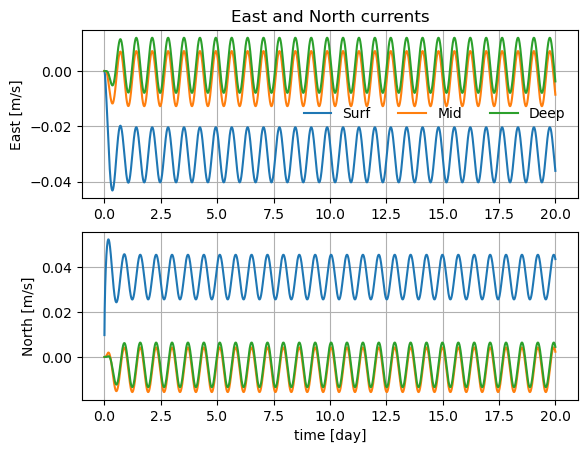

In [12]:
# %% time series at different depths
dtime = time / SECPERDAY
fig2, (ax3, ax4) = plt.subplots(2, 1)
ax3.plot(dtime, usurf, dtime, umid, dtime, udeep)
ax3.set_ylabel('East [m/s]')
ax3.grid(True)
ax3.legend(['Surf', 'Mid', 'Deep'], ncol=3, frameon=False)
ax3.set_title('East and North currents')

ax4.plot(dtime, vsurf)
ax4.plot(dtime, vmid)
ax4.plot(dtime, vdeep)
ax4.set_ylabel('North [m/s]')
ax4.set_xlabel('time [day]')
ax4.grid(True)

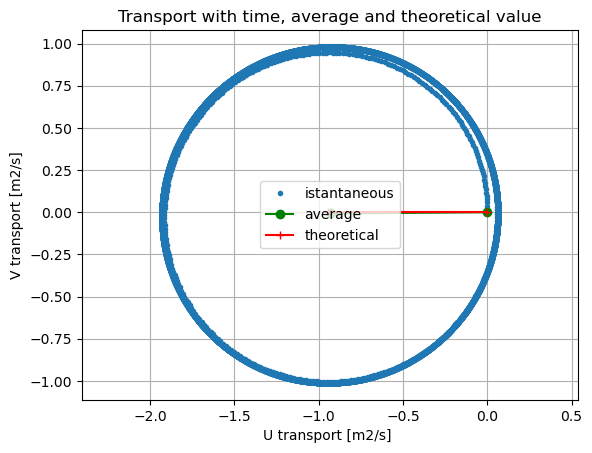

In [13]:
# %% transport
fig3 = plt.figure()
plt.plot(transu, transv, '.')
Tx = np.mean(transu)
Ty = np.mean(transv)
plt.plot([0, Tx], [0, Ty], 'g-o')
plt.plot([0, Ektrans], [0, 0], 'r-+')
plt.xlabel('U transport [m2/s] ')
plt.ylabel('V transport [m2/s]')
# plt.axis([-0.1, 0.15, -0.25, 0.])
plt.axis('equal')
plt.title('Transport with time, average and theoretical value')
plt.grid(True)
plt.legend(['istantaneous', 'average', 'theoretical'])

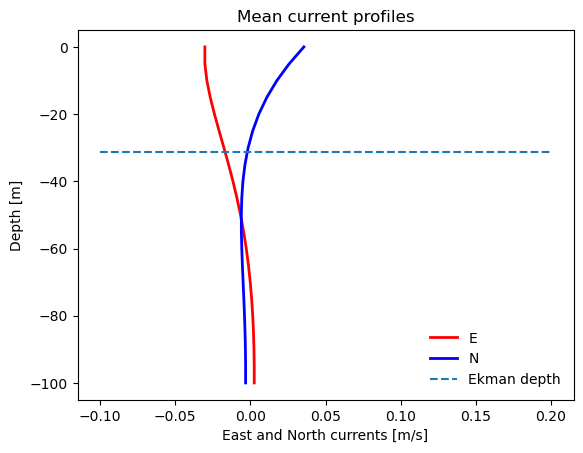

In [14]:
# %% mean velocity profiles
fig4 = plt.figure()
plt.plot(uavg, z, 'r', vavg, z, 'b', linewidth=2)
plt.xlabel('East and North currents [m/s]')
plt.ylabel('Depth [m]')
plt.title('Mean current profiles')
h = plt.plot([-0.1, 0.2], [-Ekdepth, -Ekdepth], linestyle='--')
plt.legend(['E', 'N', 'Ekman depth'], loc='lower right', frameon=False)

Text(0.5, 1.0, 'Hodograph, dz = 2.5 m')

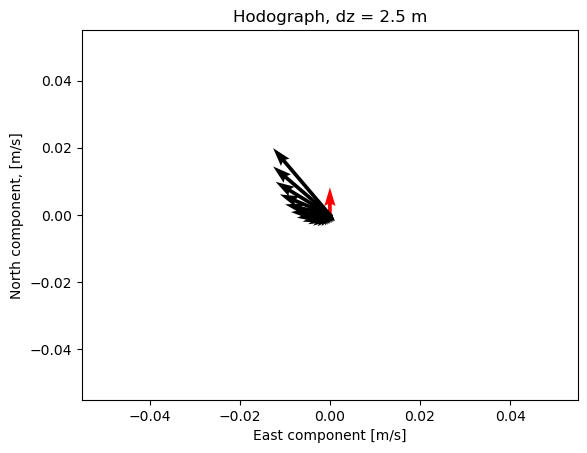

In [15]:
# %% hodograph
fig5 = plt.figure()
zeroz = np.zeros_like(uavg)
plt.quiver(0, 0, 0, 0.06, color='r')
plt.quiver(zeroz, zeroz, uavg, vavg)
plt.xlabel('East component [m/s]')
plt.ylabel('North component, [m/s]')
plt.title('Hodograph, dz = 2.5 m')

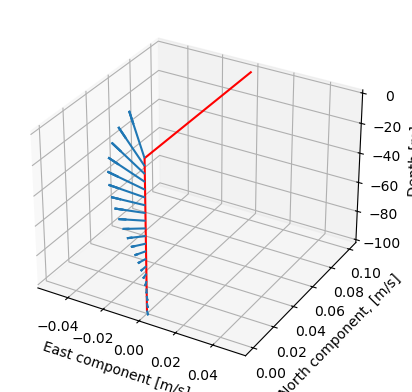

In [16]:
# %% spiral in 3D
fig6 = plt.figure()
ax6 = fig6.add_subplot(projection='3d')
h1 = ax6.quiver(zeroz, zeroz, z, uavg, vavg, zeroz)
x3 = [0, 0, 0]
y3 = [0, 0, 0.1]
z3 = [-L, 0, 0]
h2 = ax6.plot(x3, y3, z3, 'r-', linewidth=1.5)
ax6.set_xlabel('East component [m/s]')
ax6.set_ylabel('North component, [m/s]')
ax6.set_zlabel('Depth [m]')
ax6.grid(True)

plt.show()